In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [37]:
df = pd.read_csv('CC_GENERAL.csv')

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [40]:
df.shape

(8950, 18)

In [41]:
try:
    df.info()
except NameError:
    print("Error: The 'df' DataFrame is not defined. This is likely due to the previous cell (X1J_ZFuskhn3) failing to load the 'CC_GENERAL.csv' file.")
    print("Please ensure 'CC_GENERAL.csv' is present at the specified path '/content/drive/My Drive/CC_GENERAL.csv' or update the file path in cell X1J_ZFuskhn3.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [42]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [43]:
df.drop('CUST_ID', axis=1, inplace=True)

In [44]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [45]:
df.fillna(df.mean(), inplace=True)

In [46]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


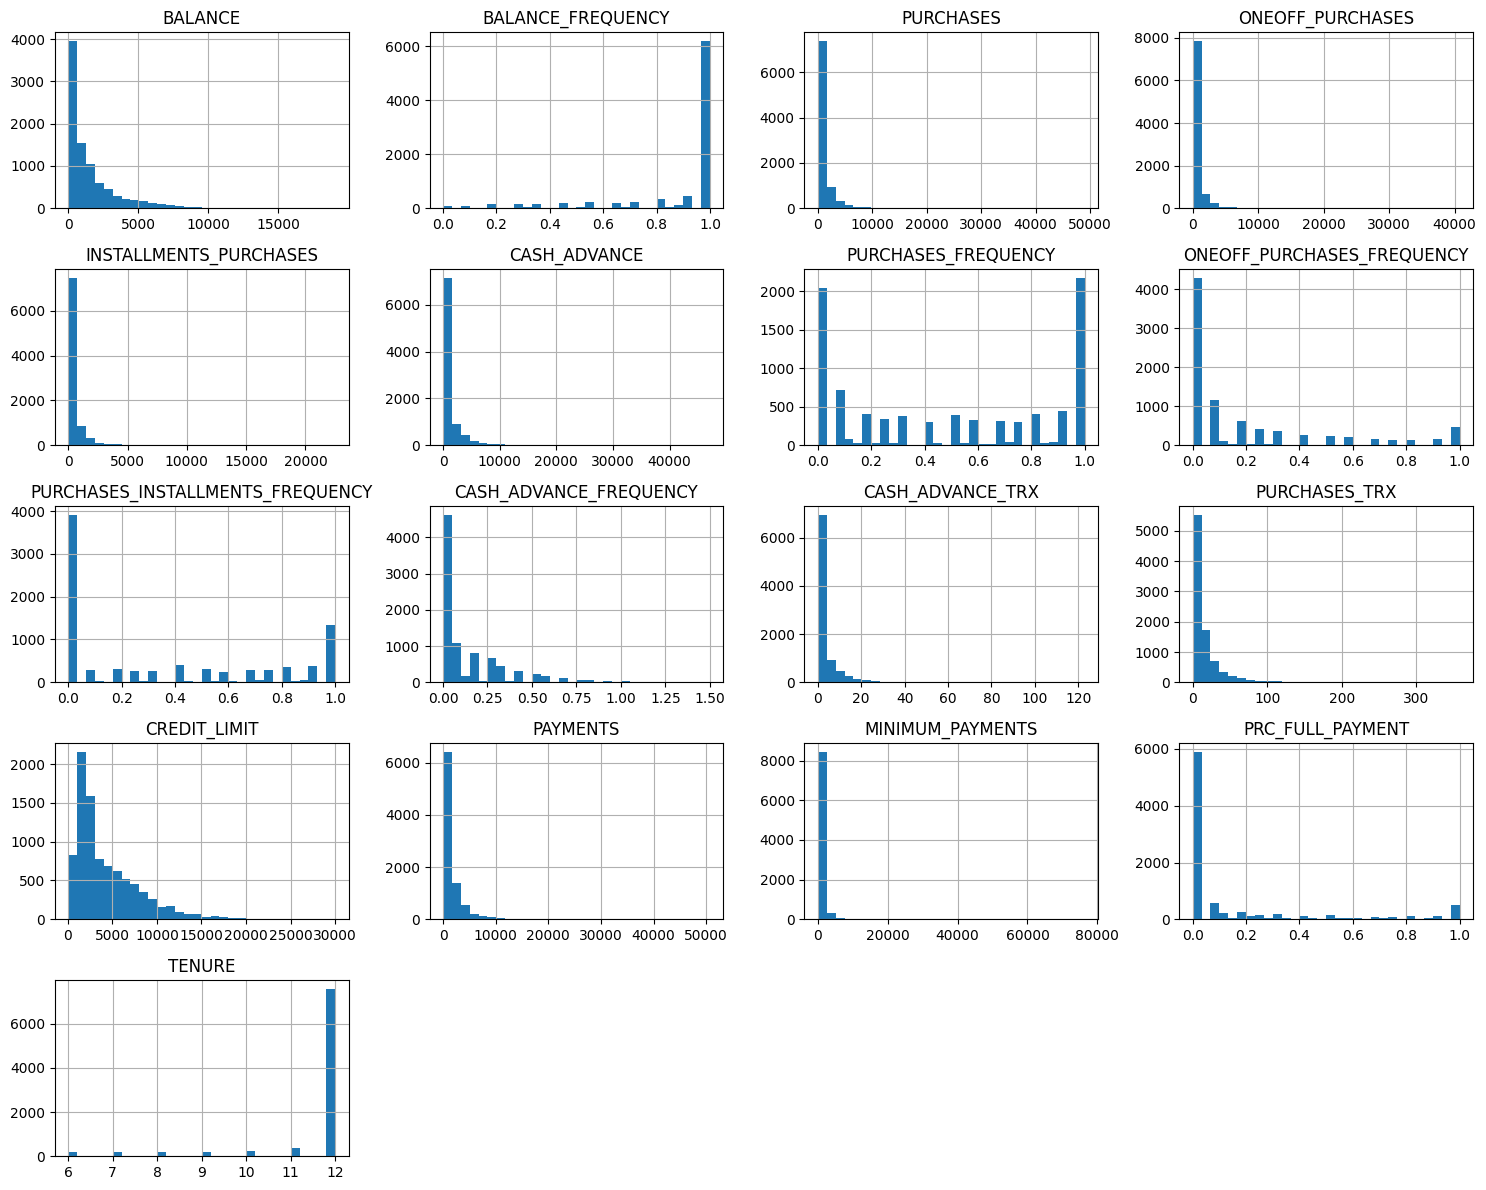

In [47]:
df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

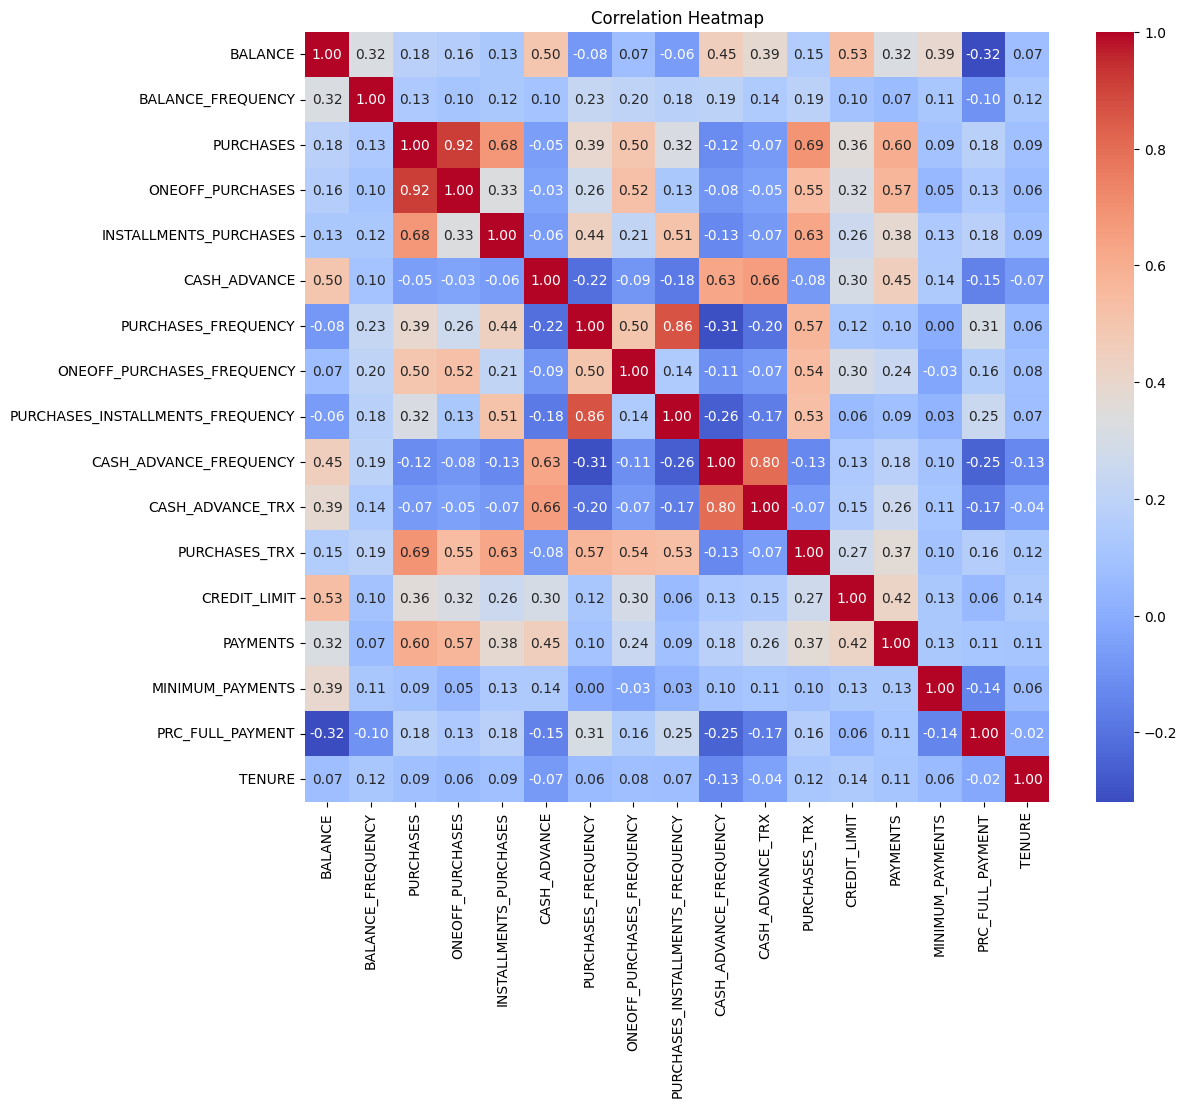

In [48]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

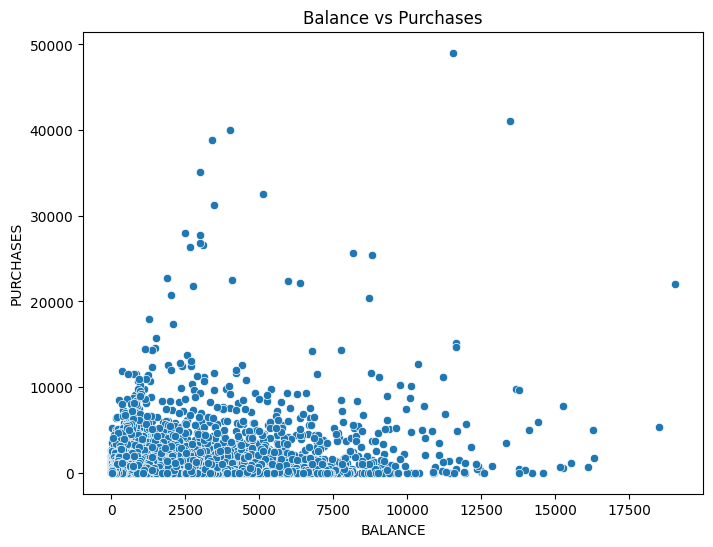

In [49]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='BALANCE', y='PURCHASES')
plt.title('Balance vs Purchases')
plt.show()

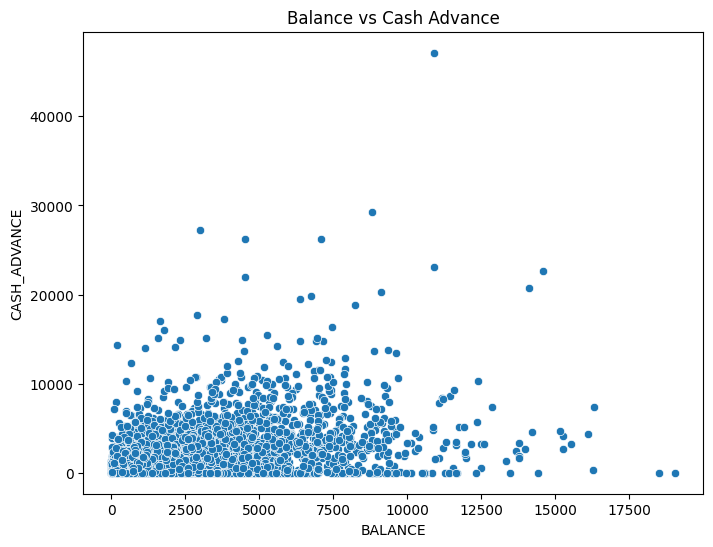

In [50]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='BALANCE', y='CASH_ADVANCE')
plt.title('Balance vs Cash Advance')
plt.show()

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [52]:
inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

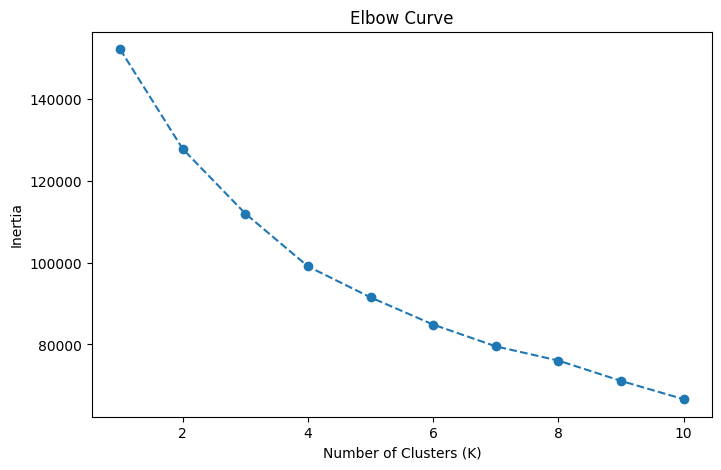

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

In [54]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

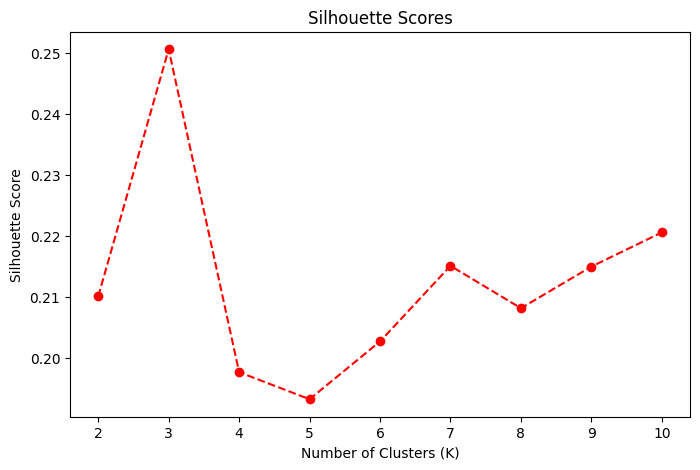

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='red', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [56]:
silhouette_df = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': silhouette_scores
})
print(silhouette_df)

    K  Silhouette Score
0   2          0.210033
1   3          0.250556
2   4          0.197607
3   5          0.193169
4   6          0.202639
5   7          0.215038
6   8          0.208092
7   9          0.214912
8  10          0.220518


In [57]:
final_k = 4
final_model = KMeans(n_clusters=final_k, random_state=42, n_init=10)
final_cluster_labels = final_model.fit_predict(X_scaled)

In [58]:
df['Cluster'] = final_cluster_labels

In [59]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


In [60]:
cluster_summary = df.groupby('Cluster').mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,650.167072,0.269258,11.594595
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1976.815179,0.286707,11.951100
2,4602.462714,0.968415,501.896219,320.373681,181.607404,4520.724309,0.287731,0.138934,0.185516,0.484526,14.284641,7.661102,7546.957050,3481.145990,2008.251157,0.034859,11.387312
3,1011.751528,0.789871,269.973466,209.853863,60.386625,595.759339,0.170146,0.086281,0.080578,0.114833,2.125503,2.903421,3277.703165,974.505090,586.301239,0.078001,11.446429


In [61]:
df['Cluster'].value_counts()

,count
Cluster,
3,3976
0,3367
2,1198
1,409


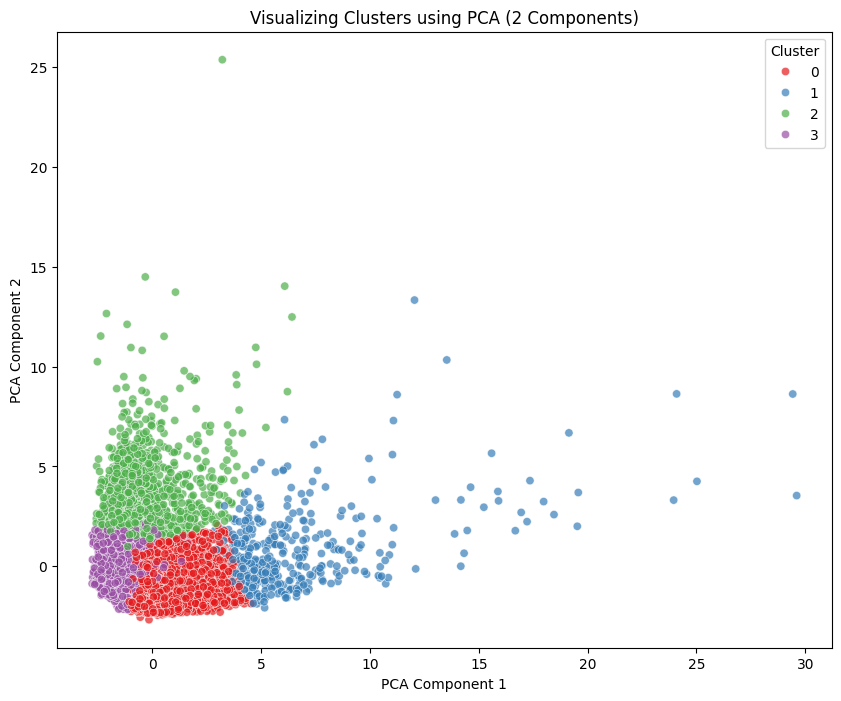

In [62]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='Set1', alpha=0.7)
plt.title('Visualizing Clusters using PCA (2 Components)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

# %% [markdown]

In [63]:
# %% [markdown]
# ## 10. Final Questions Answers
"""
1. Why is this an unsupervised learning problem?
Answer: Because the dataset does not contain any target labels or predefined groups. The algorithm automatically learns patterns and groups customers based on similarity.

2. Why did we remove the `CUST_ID` column?
Answer: Because it is a unique identifier that does not represent any financial behavior. Leaving it would distort distance calculations.

3. Which columns had missing values?
Answer: CREDIT_LIMIT and MINIMUM_PAYMENTS.

4. How did you handle the missing values?
Answer: They were handled using Mean Imputation (replacing missing values with the average value of each column).

5. Why is scaling important before applying K-Means?
Answer: K-Means calculates Euclidean distance. Features with large scales (like BALANCE in thousands) would dominate features with small scales (like frequencies between 0 and 1) if not scaled.

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.
Answer: K = 4 was chosen. The elbow curve showed an inflection point around K=4, and combined with the silhouette score, K=4 provided the most balanced and interpretable customer segmentation.

7. Based on the cluster summary table, describe each customer segment in your own words.
Answer:
- Cluster 0: Low-activity customers with minimal purchases or cash advances (Inactive users).
- Cluster 1: High cash-advance users who borrow cash frequently but rarely make direct purchases.
- Cluster 2: Active buyers with moderate spending and steady credit card usage.
- Cluster 3: High-value VIP customers with massive purchase amounts and high credit limits.

8. Which cluster may represent high-value customers?
Answer: Cluster 3 (highest average PURCHASES and CREDIT_LIMIT).

9. Which cluster may represent customers who rely more on cash advance?
Answer: Cluster 1 (highest average CASH_ADVANCE and CASH_ADVANCE_FREQUENCY).

10. How can a company use these clusters for marketing strategy?
Answer:
- For VIPs (Cluster 3): Offer premium rewards and high cashback incentives.
- For Cash Advance Users (Cluster 1): Promote lower-interest installment plans for purchases.
- For Inactive Users (Cluster 0): Send activation offers and discounts to stimulate card usage.
"""

'\n1. Why is this an unsupervised learning problem?\nAnswer: Because the dataset does not contain any target labels or predefined groups. The algorithm automatically learns patterns and groups customers based on similarity.\n\n2. Why did we remove the `CUST_ID` column?\nAnswer: Because it is a unique identifier that does not represent any financial behavior. Leaving it would distort distance calculations.\n\n3. Which columns had missing values?\nAnswer: CREDIT_LIMIT and MINIMUM_PAYMENTS.\n\n4. How did you handle the missing values?\nAnswer: They were handled using Mean Imputation (replacing missing values with the average value of each column).\n\n5. Why is scaling important before applying K-Means?\nAnswer: K-Means calculates Euclidean distance. Features with large scales (like BALANCE in thousands) would dominate features with small scales (like frequencies between 0 and 1) if not scaled.\n\n6. Which K value did you choose? Explain your answer using the elbow method and silhouette sc